# FathomNet 2026 — Final Pipeline

End-to-end walkthrough of the final composite pipeline that scored **0.1143 mAP@[.50:.95]** on the public leaderboard:

> **Slot 9** = E27 cross-arch detector ensemble → Path A consensus relabel (DINOv2 + k-NN + MLP unanimous) → WBF stack of peer relabel variants → letterbox-border noise filter.

This notebook is committed with cached outputs — you can read the results without running it. To re-run, follow [`SETUP.md`](../SETUP.md) for environment, data, and weights, then `Cell → Run All`.

Sections:
1. Experiment scoreboard (all 28 scored submissions — Phase 1–6 training + Phase 7 post-submission)
2. Per-class AP on the proxy validation set
3. Final pipeline (pseudocode + composition)
4. Headline numbers summary

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path('..').resolve()
FIGURES_DIR = PROJECT_ROOT / 'figures'

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
})

print(f'Project root: {PROJECT_ROOT}')
print(f'Figures dir: {FIGURES_DIR}')
print(f'Figures present: {sorted(p.name for p in FIGURES_DIR.glob("*"))}')

Project root: C:\Users\navya\OneDrive\Documentos\projects\fathomnet-2026
Figures dir: C:\Users\navya\OneDrive\Documentos\projects\fathomnet-2026\figures
Figures present: ['per_class_metrics.csv', 'sample_test_images.png', 'train_vs_test_contact_sheet.jpg']


## 1. Experiment scoreboard

Every scored Kaggle submission, in chronological order across both phases (Phase 1–6 model training, Phase 7 post-submission optimization). Four colors:
- **Green** — lifted the leaderboard (`INCLUDE`)
- **Red** — hurt the leaderboard (`EXCLUDE`)
- **Orange** — hurt solo but useful as an ensemble component (`EXCLUDE-S`)
- **Blue** — the final winning Slot 9 composite

The dashed line marks the E1 anchor (LB 0.0863). The dotted line marks the E27 training-phase best (LB 0.0917). The star marks Slot 9, the final post-submission composite (LB 0.1143).

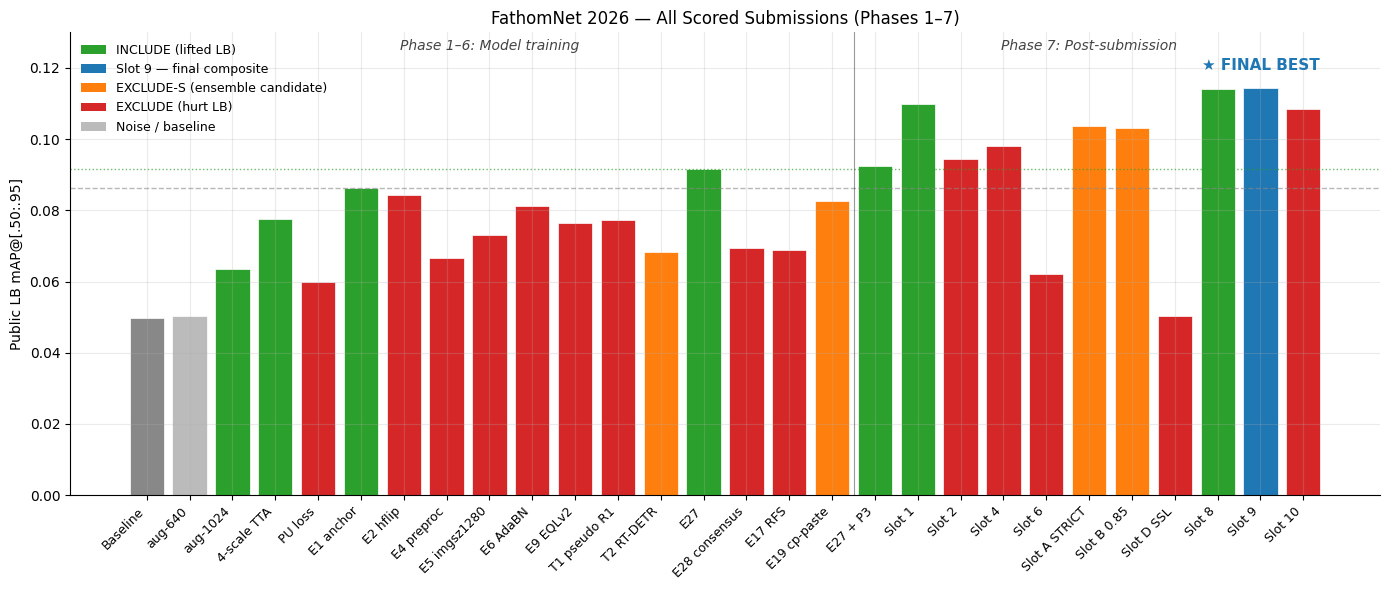

Best LB:        0.1143  (Slot 9 — Phase 7 final composite)
Pure-model:     0.0917  (E27 — Phase 6 cross-arch ensemble)
Anchor:         0.0863  (E1 — YOLOv8x + 6-scale TTA WBF)
Phase 7 lift:   +0.0226  (E27 → Slot 9, post-submission optimization)
Total lift:     +0.0645  (Baseline → Slot 9)


In [2]:
experiments = [
    # ===== Phase 1-6: Model training =====
    ('Baseline',       0.0498, 'baseline'),
    ('aug-640',        0.0502, 'noise'),
    ('aug-1024',       0.0635, 'include'),
    ('4-scale TTA',    0.0775, 'include'),
    ('PU loss',        0.0600, 'exclude'),
    ('E1 anchor',      0.0863, 'include'),
    ('E2 hflip',       0.0844, 'exclude'),
    ('E4 preproc',     0.0665, 'exclude'),
    ('E5 imgsz1280',   0.0730, 'exclude'),
    ('E6 AdaBN',       0.0811, 'exclude'),
    ('E9 EQLv2',       0.0765, 'exclude'),
    ('T1 pseudo R1',   0.0773, 'exclude'),
    ('T2 RT-DETR',     0.0684, 'exclude-s'),
    ('E27',            0.0917, 'include'),
    ('E28 consensus',  0.0695, 'exclude'),
    ('E17 RFS',        0.0689, 'exclude'),
    ('E19 cp-paste',   0.0827, 'exclude-s'),
    # ===== Phase 7: Post-submission optimization =====
    ('E27 + P3',       0.0924, 'include'),
    ('Slot 1',         0.1098, 'include'),
    ('Slot 2',         0.0945, 'exclude'),
    ('Slot 4',         0.0981, 'exclude'),
    ('Slot 6',         0.0622, 'exclude'),
    ('Slot A STRICT',  0.1038, 'exclude-s'),
    ('Slot B 0.85',    0.1031, 'exclude-s'),
    ('Slot D SSL',     0.0504, 'exclude'),
    ('Slot 8',         0.1141, 'include'),
    ('Slot 9',         0.1143, 'best'),
    ('Slot 10',        0.1086, 'exclude'),
]

color_map = {
    'baseline':  '#888888',
    'noise':     '#bbbbbb',
    'include':   '#2ca02c',
    'exclude':   '#d62728',
    'exclude-s': '#ff7f0e',
    'best':      '#1f77b4',
}

names = [e[0] for e in experiments]
scores = [e[1] for e in experiments]
colors = [color_map[e[2]] for e in experiments]
phase_boundary = 17  # first 17 entries are Phase 1-6; remainder are Phase 7

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(experiments)), scores, color=colors, edgecolor='white', linewidth=0.5)

# Reference lines
ax.axhline(0.0863, color='#888888', linestyle='--', linewidth=1, alpha=0.6, label='E1 anchor (0.0863)')
ax.axhline(0.0917, color='#2ca02c', linestyle=':',  linewidth=1, alpha=0.7, label='E27 training-phase best (0.0917)')

# Phase boundary separator
ax.axvline(phase_boundary - 0.5, color='black', linestyle='-', linewidth=0.8, alpha=0.4)
ax.text(phase_boundary / 2 - 0.5, 0.125, 'Phase 1–6: Model training',
        ha='center', fontsize=10, color='#444', style='italic')
ax.text(phase_boundary + (len(experiments) - phase_boundary) / 2 - 0.5, 0.125,
        'Phase 7: Post-submission',
        ha='center', fontsize=10, color='#444', style='italic')

ax.set_xticks(range(len(experiments)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Public LB mAP@[.50:.95]')
ax.set_title('FathomNet 2026 — All Scored Submissions (Phases 1–7)')
ax.set_ylim(0, 0.13)

# Star the final winner
best_idx = next(i for i, e in enumerate(experiments) if e[2] == 'best')
ax.annotate('★ FINAL BEST', xy=(best_idx, scores[best_idx]),
            xytext=(best_idx, scores[best_idx] + 0.005),
            ha='center', fontsize=11, fontweight='bold', color='#1f77b4')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_map['include'],   label='INCLUDE (lifted LB)'),
    Patch(facecolor=color_map['best'],      label='Slot 9 — final composite'),
    Patch(facecolor=color_map['exclude-s'], label='EXCLUDE-S (ensemble candidate)'),
    Patch(facecolor=color_map['exclude'],   label='EXCLUDE (hurt LB)'),
    Patch(facecolor=color_map['noise'],     label='Noise / baseline'),
]
ax.legend(handles=legend_elements, loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print(f'Best LB:        {max(scores):.4f}  ({experiments[best_idx][0]} — Phase 7 final composite)')
print(f'Pure-model:     0.0917  (E27 — Phase 6 cross-arch ensemble)')
print(f'Anchor:         0.0863  (E1 — YOLOv8x + 6-scale TTA WBF)')
print(f'Phase 7 lift:   +{max(scores) - 0.0917:.4f}  (E27 → Slot 9, post-submission optimization)')
print(f'Total lift:     +{max(scores) - 0.0498:.4f}  (Baseline → Slot 9)')

## 2. Per-class AP on the proxy validation set

Loaded from `figures/per_class_metrics.csv` (computed with `scripts/eval_per_class_confusion.py` on the fold-0 proxy validation set). The bars are sorted by AP@[.50:.95]. The dotted line is the macro-averaged AP across all 32 classes.

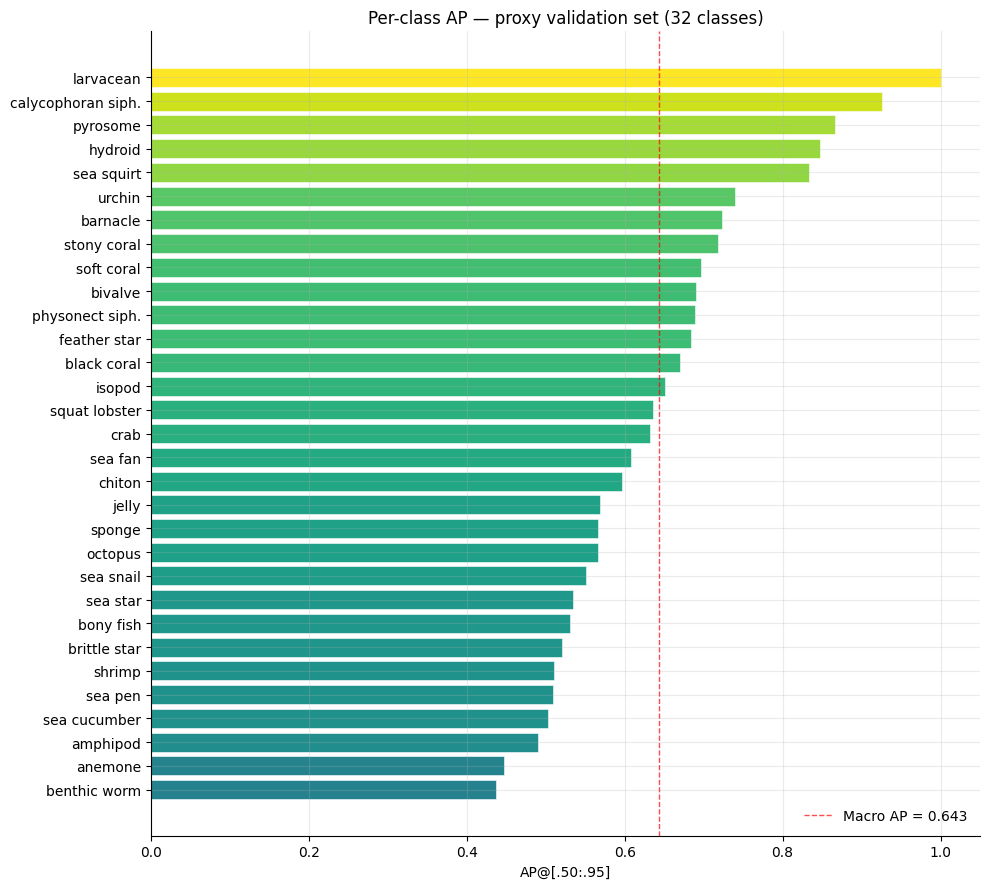

Top 5 classes by AP@[.50:.95]:
             class       AP  n_gt
         larvacean 1.000000     1
calycophoran siph. 0.925743     4
          pyrosome 0.866337     3
           hydroid 0.847030     6
        sea squirt 0.833663     4

Bottom 5 classes by AP@[.50:.95]:
       class       AP  n_gt
benthic worm 0.437353    33
     anemone 0.447071   281
    amphipod 0.490801    57
sea cucumber 0.502910   108
     sea pen 0.509643    21


In [3]:
metrics = pd.read_csv(FIGURES_DIR / 'per_class_metrics.csv')
metrics = metrics.sort_values('AP', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = plt.cm.viridis(metrics['AP'] / metrics['AP'].max())
bars = ax.barh(metrics['class'], metrics['AP'], color=colors, edgecolor='white', linewidth=0.4)

macro_ap = metrics['AP'].mean()
ax.axvline(macro_ap, color='red', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Macro AP = {macro_ap:.3f}')

ax.set_xlabel('AP@[.50:.95]')
ax.set_title('Per-class AP — proxy validation set (32 classes)')
ax.set_xlim(0, 1.05)
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

# Print a small ranked table
print('Top 5 classes by AP@[.50:.95]:')
top5 = metrics.nlargest(5, 'AP')[['class', 'AP', 'n_gt']]
print(top5.to_string(index=False))
print()
print('Bottom 5 classes by AP@[.50:.95]:')
bottom5 = metrics.nsmallest(5, 'AP')[['class', 'AP', 'n_gt']]
print(bottom5.to_string(index=False))

## 3. Final pipeline

The final submission (Slot 9) is a composite of two phases. Phase 6 ends at the E27 cross-architecture detector ensemble (LB 0.0917). Phase 7 applies three composable post-submission operations on top of it (LB → 0.1143):

```
                         ┌──────────────────────────────────────────┐
                         │  Phase 6 — detector ensemble             │
                         │                                          │
   raw test image ──►    │   YOLOv8x (E1) ──┐                       │
                         │                   ├─► WBF(1.0, 1.0)  E27 │ ─► LB 0.0917
                         │   RT-DETR-l (T2) ─┘                       │
                         └──────────────────────────────────────────┘
                                          │
                                          ▼
                         ┌──────────────────────────────────────────┐
                         │  Phase 7 — post-submission optimization  │
                         │                                          │
                         │  (a) P3 laser-dot suppression  ──────────│ ─► LB 0.0924
                         │                                          │
                         │  (b) Path A consensus relabel:           │
                         │      DINOv2 features → kNN AND MLP       │
                         │      Unanimous rule, ~3,062 relabels     │ ─► Slot 1
                         │                                          │   LB 0.1098
                         │  (c) WBF stack of peer variants:         │
                         │      {E27, Slot 1, Slot A, Slot B}       │
                         │      weights (0.5, 1.5, 0.7, 0.7)        │ ─► Slot 8
                         │                                          │   LB 0.1141
                         │  (d) Letterbox-border noise filter:      │
                         │      drop low-conf boxes in black bars   │ ─► Slot 9 ★
                         │                                          │   LB 0.1143
                         └──────────────────────────────────────────┘
```

Running the full pipeline requires the trained weights (see [`weights/README.md`](../weights/README.md)) and ~20 minutes of GPU inference for Phase 6 plus ~2 hours of CPU work for Phase 7. The pseudocode below shows the call sites; it is not executed in this notebook.

In [4]:
# Pseudocode — DO NOT EXECUTE without trained weights and competition data.
# See scripts/predict_test_multiscale_tta.py, scripts/cross_arch_ensemble.py,
# and the Phase 7 utilities in src/.

PIPELINE = '''
# =============================================================================
# Phase 6 — Train the two detector ensemble members and produce E27
# =============================================================================
python scripts/train_phase2_baseline.py \\
    --init weights/mbari_315k/best.pt \\
    --epochs 50 --imgsz 1024 --fold 0 \\
    --name p2_aug_e50_1024_fold0

python scripts/train_rtdetr.py \\
    --epochs 50 --imgsz 1024 --fold 0 \\
    --name t2_rtdetr_l_fold0

# 6-scale TTA + WBF for each model
python scripts/predict_test_multiscale_tta.py \\
    --weights weights/runs/p2_aug_e50_1024_fold0/weights/best.pt \\
    --scales 480 640 832 1024 1280 1536 \\
    --out submissions/e1.csv

python scripts/predict_test_multiscale_tta.py \\
    --weights weights/runs/t2_rtdetr_l_fold0/weights/best.pt \\
    --scales 480 640 832 1024 1280 1536 \\
    --out submissions/t2.csv

# Cross-architecture WBF — E27 (LB 0.0917)
python scripts/cross_arch_ensemble.py \\
    --submissions submissions/e1.csv submissions/t2.csv \\
    --weights 1.0 1.0 --iou-thr 0.55 --skip-box-thr 0.0001 \\
    --out submissions/e27.csv

# =============================================================================
# Phase 7 — Post-submission optimization (LB 0.0917 → 0.1143)
# =============================================================================

# (a) P3 laser-dot geometric suppression — defensive baseline (LB 0.0924)
python -m src.p3_laser_dot_suppress \\
    --in submissions/e27.csv --out submissions/e27_p3.csv

# (b) Path A consensus relabel — DINOv2 + k-NN + MLP unanimous (Slot 1, LB 0.1098)
python -m src.path_a_consensus \\
    --base submissions/e27_p3.csv \\
    --features dinov2_vit_l14_frozen \\
    --classifiers knn mlp_32way \\
    --rule unanimous_disagreement \\
    --out submissions/slot_1.csv

# Peer relabel variants for the WBF stack
python -m src.path_a_consensus \\
    --base submissions/e27_p3.csv --features dinov2_ft \\
    --classifiers knn mlp_32way --rule unanimous_disagreement \\
    --out submissions/slot_a_strict.csv
python -m src.path_a_consensus \\
    --base submissions/e27_p3.csv --features dinov2_vit_l14_frozen \\
    --classifiers mlp_32way --threshold 0.85 \\
    --out submissions/slot_b_085.csv

# (c) WBF stack with asymmetric weights — Slot 8 (LB 0.1141)
python scripts/cross_arch_ensemble.py \\
    --submissions submissions/e27.csv \\
                  submissions/slot_1.csv \\
                  submissions/slot_a_strict.csv \\
                  submissions/slot_b_085.csv \\
    --weights 0.5 1.5 0.7 0.7 \\
    --iou-thr 0.55 --skip-box-thr 0.0001 \\
    --out submissions/slot_8.csv

# (d) Letterbox-border noise filter — Slot 9, FINAL BEST (LB 0.1143)
python -m src.letterbox_border_filter \\
    --in submissions/slot_8.csv \\
    --mean-rgb-thresh 15 --min-depth 5 \\
    --out submissions/slot_9.csv

# Final submit
kaggle competitions submit -c fathomnet-2026 \\
    -f submissions/slot_9.csv \\
    -m "Slot 9 — E27 + Path A consensus + WBF stack + border filter"
'''

print(PIPELINE)


# =============================================================================
# Phase 6 — Train the two detector ensemble members and produce E27
# =============================================================================
python scripts/train_phase2_baseline.py \
    --init weights/mbari_315k/best.pt \
    --epochs 50 --imgsz 1024 --fold 0 \
    --name p2_aug_e50_1024_fold0

python scripts/train_rtdetr.py \
    --epochs 50 --imgsz 1024 --fold 0 \
    --name t2_rtdetr_l_fold0

# 6-scale TTA + WBF for each model
python scripts/predict_test_multiscale_tta.py \
    --weights weights/runs/p2_aug_e50_1024_fold0/weights/best.pt \
    --scales 480 640 832 1024 1280 1536 \
    --out submissions/e1.csv

python scripts/predict_test_multiscale_tta.py \
    --weights weights/runs/t2_rtdetr_l_fold0/weights/best.pt \
    --scales 480 640 832 1024 1280 1536 \
    --out submissions/t2.csv

# Cross-architecture WBF — E27 (LB 0.0917)
python scripts/cross_arch_ensemble.py \
    --submissions submis

## 4. Headline numbers

Summary of the final result and the levers that produced it.

In [5]:
headline = pd.DataFrame([
    ('Final leaderboard rank',               '14th',    'Public leaderboard, FathomNet 2026 / CLEF 2026'),
    ('Best public LB',                       '0.1143',  'Slot 9 — E27 + Path A consensus + WBF stack + border filter'),
    ('Best pure-model result',               '0.0917',  'E27 — YOLOv8x + RT-DETR-l cross-arch ensemble'),
    ('Anchor (single model)',                '0.0863',  'YOLOv8x + MBARI 315k init + 6-scale TTA WBF'),
    ('Phase 7 lift over E27',                '+0.0226', 'Post-submission optimization on top of detector ensemble'),
    ('Phase 7 lift over E27+P3 (relative)',  '+23.7%',  'Composite chain: consensus relabel → WBF stack → border filter'),
    ('Cross-arch ensemble lift over anchor', '+0.0054', 'WBF(E1, T2) equal weights, iou_thr=0.55'),
    ('Resolution lift (640 → 1024)',         '+0.0137', 'Biggest single training-phase lever'),
    ('TTA lift (1-scale → 6-scale)',         '+0.0228', 'Composes cleanly with resolution'),
    ('Pretrained init lift (COCO → MBARI)',  '+0.078',  'Bake-off measured on fold-0 val'),
    ('Submissions scored',                    28,       '17 training + 11 post-submission'),
    ('Lifters',                               8,        'aug-1024, 4-scale, E1, E27, E27+P3, Slot 1, Slot 8, Slot 9'),
], columns=['Metric', 'Value', 'Notes'])

print(headline.to_string(index=False))

                              Metric   Value                                                          Notes
              Final leaderboard rank    14th                 Public leaderboard, FathomNet 2026 / CLEF 2026
                      Best public LB  0.1143    Slot 9 — E27 + Path A consensus + WBF stack + border filter
              Best pure-model result  0.0917                  E27 — YOLOv8x + RT-DETR-l cross-arch ensemble
               Anchor (single model)  0.0863                    YOLOv8x + MBARI 315k init + 6-scale TTA WBF
               Phase 7 lift over E27 +0.0226       Post-submission optimization on top of detector ensemble
 Phase 7 lift over E27+P3 (relative)  +23.7% Composite chain: consensus relabel → WBF stack → border filter
Cross-arch ensemble lift over anchor +0.0054                        WBF(E1, T2) equal weights, iou_thr=0.55
        Resolution lift (640 → 1024) +0.0137                            Biggest single training-phase lever
        TTA lift (1-scale → 

## Reading order from here

- [`README.md`](../README.md) — project overview, headline numbers, what worked / what didn't, full experiments table, key insights, limitations
- [`SETUP.md`](../SETUP.md) — install + how to run training and inference end-to-end